# Action Potential Amplitude Analysis Pipeline

This notebook provides a reproducible Python workflow for extracting action-potential amplitude values from current-clamp electrophysiological recordings exported from HEKA/PatchMaster ASCII files.

The pipeline includes:

- HEKA ASCII file import
- action-potential peak detection
- local baseline estimation before each action potential
- action-potential amplitude calculation
- batch analysis of recordings
- export of analysis results tables
- representative quality-control visualization

The primary amplitude metric is calculated as:

**AP amplitude = AP peak − median local membrane potential measured 20–5 ms before the AP peak**

Recording names and experimental conditions are anonymized in this public version to protect unpublished experimental details.

## Workflow Overview

1. Import libraries
2. User settings
3. HEKA ASCII loader
4. Spike detection and amplitude algorithm
5. Batch amplitude analysis
6. Export results
7. Quality-control analysis
8. Representative quality-control visualization

In [1]:
# ========================================
# MASTER SETUP CELL
# Run this first
# ========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

print("Setup complete")

Mounted at /content/drive
Setup complete


In [2]:
# ============================================================
# USER SETTINGS
# ============================================================

# Path containing HEKA/PatchMaster ASCII files
BASE_PATH = "/content/drive/MyDrive/PatchClampData/Python2/"

# Recordings included in the public workflow
# These names are anonymized for GitHub.
# In a real analysis, replace these with the names of your exported .asc files.
FILE_LIST = [
    "recording_01.asc",
    "recording_02.asc",
    "recording_03.asc"
]

# Generic group name used in exported tables
CONDITION_NAME = "Example_Group"

# Analysis window
START_TIME_S = 0.3
END_TIME_S = 60.0

# Spike peak detection
MIN_PEAK_MV = 0
MIN_PROMINENCE_MV = 20
REFRACTORY_PERIOD_S = 0.05

# Local baseline window before each AP peak
# Primary amplitude = AP peak - median Vm 20–5 ms before AP peak
LOCAL_BASELINE_START_MS = 20
LOCAL_BASELINE_END_MS = 5

# Optional AP-onset detection using dV/dt
PRE_SPIKE_WINDOW_MS = 30
DVDT_THRESHOLD_MV_PER_MS = 10

# QC amplitude thresholds
# These are informational only; no automatic exclusion is applied.
QC_LOW_AMPLITUDE_MV = 20
QC_HIGH_AMPLITUDE_MV = 120

# Plot settings
Y_MIN = -90
Y_MAX = 50

# Output file names
RECORDING_SUMMARY_CSV_NAME = "amplitude_recording_summary.csv"
SPIKE_BY_SPIKE_CSV_NAME = "amplitude_spike_by_spike_table.csv"
GRAPHPAD_CSV_NAME = "graphpad_amplitude_mV.csv"

print("User settings loaded")

User settings loaded


In [3]:
# ============================================================
# HEKA / PATCHMASTER ASCII FILE IMPORT
# ============================================================

def load_heka_ascii_voltage(file_path):
    """
    Load a HEKA/PatchMaster ASCII file exported from current-clamp recordings.

    Expected columns include:
    - Index
    - Time[s]
    - V-mon[V]
    - Stimulus

    Returns
    -------
    data : pandas.DataFrame
        DataFrame containing:
        - Time_s
        - Voltage_mV
    """

    header_line = None

    with open(file_path, "r") as f:
        for line_number, line in enumerate(f):
            cleaned = line.strip()

            if cleaned.startswith('"Index"') or cleaned.startswith("Index"):
                header_line = line_number
                break

    if header_line is None:
        raise ValueError(f"HEKA header not found: {file_path}")

    data = pd.read_csv(
        file_path,
        sep=",",
        skiprows=header_line
    )

    data.columns = (
        data.columns
        .str.strip()
        .str.replace('"', "", regex=False)
    )

    time_col = next(col for col in data.columns if "Time[s]" in col)
    voltage_col = next(col for col in data.columns if "V-mon[V]" in col)

    data = data[[time_col, voltage_col]].copy()
    data.columns = ["Time_s", "Voltage_V"]

    data["Time_s"] = pd.to_numeric(data["Time_s"], errors="coerce")
    data["Voltage_V"] = pd.to_numeric(data["Voltage_V"], errors="coerce")

    data = data.dropna().reset_index(drop=True)

    # Convert voltage from V to mV
    data["Voltage_mV"] = data["Voltage_V"] * 1000

    return data[["Time_s", "Voltage_mV"]]


print("HEKA ASCII loader ready")

HEKA ASCII loader ready


In [4]:
# ============================================================
# ACTION-POTENTIAL AMPLITUDE EXTRACTION ALGORITHM
# ============================================================

def analyze_amplitude_recording(
    file_path,
    recording_name,
    condition_name=CONDITION_NAME,
    start_time_s=START_TIME_S,
    end_time_s=END_TIME_S,
    min_peak_mV=MIN_PEAK_MV,
    min_prominence_mV=MIN_PROMINENCE_MV,
    refractory_period_s=REFRACTORY_PERIOD_S,
    local_baseline_start_ms=LOCAL_BASELINE_START_MS,
    local_baseline_end_ms=LOCAL_BASELINE_END_MS,
    pre_spike_window_ms=PRE_SPIKE_WINDOW_MS,
    dvdt_threshold_mV_per_ms=DVDT_THRESHOLD_MV_PER_MS,
    qc_low_amplitude_mV=QC_LOW_AMPLITUDE_MV,
    qc_high_amplitude_mV=QC_HIGH_AMPLITUDE_MV,
    y_min=Y_MIN,
    y_max=Y_MAX,
    save_figure=False
):
    """
    Analyze action-potential amplitude from one current-clamp recording.

    Primary amplitude metric
    ------------------------
    AP amplitude = AP peak - median local membrane potential measured
    20–5 ms before the AP peak.

    Additional diagnostic metrics
    -----------------------------
    - AP peak voltage
    - local baseline voltage
    - optional dV/dt onset estimate
    - QC flags

    QC flags are informational only.
    No spikes or recordings are automatically excluded.
    """

    # --------------------------------------------------------
    # Load recording
    # --------------------------------------------------------

    data = load_heka_ascii_voltage(file_path)

    data = data[
        (data["Time_s"] >= start_time_s) &
        (data["Time_s"] <= end_time_s)
    ].copy()

    time_s = data["Time_s"].values
    voltage_mV = data["Voltage_mV"].values

    if len(time_s) < 10:
        raise ValueError("Selected recording window is empty or too short.")

    # --------------------------------------------------------
    # Sampling
    # --------------------------------------------------------

    dt = np.median(np.diff(time_s))

    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid sampling interval.")

    sampling_rate_Hz = 1 / dt

    minimum_distance_points = max(
        1,
        int(refractory_period_s / dt)
    )

    # --------------------------------------------------------
    # Detect action-potential peaks
    # --------------------------------------------------------

    peaks, peak_properties = find_peaks(
        voltage_mV,
        height=min_peak_mV,
        prominence=min_prominence_mV,
        distance=minimum_distance_points
    )

    if len(peaks) == 0:
        raise ValueError(
            "No action-potential peaks detected using the current parameters."
        )

    # --------------------------------------------------------
    # Optional dV/dt calculation
    # --------------------------------------------------------

    dvdt_mV_per_ms = np.gradient(voltage_mV, time_s) / 1000

    pre_spike_points = max(
        1,
        int((pre_spike_window_ms / 1000) / dt)
    )

    baseline_start_points = max(
        1,
        int((local_baseline_start_ms / 1000) / dt)
    )

    baseline_end_points = max(
        1,
        int((local_baseline_end_ms / 1000) / dt)
    )

    # --------------------------------------------------------
    # Spike-by-spike amplitude analysis
    # --------------------------------------------------------

    spike_results = []

    for spike_number, peak_idx in enumerate(peaks, start=1):

        peak_time_s = float(time_s[peak_idx])
        peak_mV = float(voltage_mV[peak_idx])

        # Local baseline: median Vm 20–5 ms before AP peak
        baseline_start_idx = peak_idx - baseline_start_points
        baseline_end_idx = peak_idx - baseline_end_points

        if baseline_start_idx >= 0 and baseline_end_idx > baseline_start_idx:

            baseline_segment = voltage_mV[
                baseline_start_idx:baseline_end_idx
            ]

            if len(baseline_segment) >= 3:
                local_baseline_mV = float(np.median(baseline_segment))
                amplitude_local_baseline_mV = peak_mV - local_baseline_mV
            else:
                local_baseline_mV = np.nan
                amplitude_local_baseline_mV = np.nan

        else:
            local_baseline_mV = np.nan
            amplitude_local_baseline_mV = np.nan

        # Optional dV/dt onset estimate
        search_start_idx = max(0, peak_idx - pre_spike_points)

        dvdt_segment = dvdt_mV_per_ms[
            search_start_idx:peak_idx
        ]

        onset_candidates = np.where(
            dvdt_segment >= dvdt_threshold_mV_per_ms
        )[0]

        if len(onset_candidates) > 0:
            onset_idx = search_start_idx + onset_candidates[0]
            onset_time_s = float(time_s[onset_idx])
            onset_mV = float(voltage_mV[onset_idx])
            amplitude_onset_mV = peak_mV - onset_mV
        else:
            onset_time_s = np.nan
            onset_mV = np.nan
            amplitude_onset_mV = np.nan

        # QC flags: informational only
        qc_flags = []

        if np.isnan(amplitude_local_baseline_mV):
            qc_flags.append("CHECK_no_baseline")
        else:
            if amplitude_local_baseline_mV < qc_low_amplitude_mV:
                qc_flags.append("CHECK_low_amplitude")

            if amplitude_local_baseline_mV > qc_high_amplitude_mV:
                qc_flags.append("CHECK_high_amplitude")

        if np.isnan(amplitude_onset_mV):
            qc_flags.append("CHECK_no_dvdt_onset")

        qc_flag = "OK" if len(qc_flags) == 0 else ";".join(qc_flags)

        spike_results.append({
            "condition": condition_name,
            "recording_name": recording_name,
            "spike_number": spike_number,
            "spike_time_s": peak_time_s,
            "peak_mV": peak_mV,
            "local_baseline_mV": local_baseline_mV,
            "amplitude_from_local_baseline_mV": amplitude_local_baseline_mV,
            "onset_time_s": onset_time_s,
            "onset_mV": onset_mV,
            "amplitude_from_onset_mV": amplitude_onset_mV,
            "qc_flag": qc_flag
        })

    spike_by_spike_df = pd.DataFrame(spike_results)

    valid_amplitudes = (
        spike_by_spike_df["amplitude_from_local_baseline_mV"]
        .dropna()
        .astype(float)
    )

    if len(valid_amplitudes) == 0:
        raise ValueError("No valid local-baseline amplitudes were obtained.")

    # --------------------------------------------------------
    # Recording-level summary
    # --------------------------------------------------------

    summary = {
        "recording_name": recording_name,
        "condition": condition_name,
        "duration_s": time_s[-1] - time_s[0],
        "sampling_rate_Hz": sampling_rate_Hz,
        "spike_count_detected": len(peaks),
        "n_valid_spikes": len(valid_amplitudes),
        "mean_amplitude_mV": valid_amplitudes.mean(),
        "median_amplitude_mV": valid_amplitudes.median(),
        "sd_amplitude_mV": valid_amplitudes.std(ddof=1),
        "sem_amplitude_mV": valid_amplitudes.std(ddof=1) / np.sqrt(len(valid_amplitudes)),
        "median_peak_mV": spike_by_spike_df["peak_mV"].median(),
        "median_local_baseline_mV": spike_by_spike_df["local_baseline_mV"].median(),
        "median_amplitude_onset_mV": spike_by_spike_df["amplitude_from_onset_mV"].median(),
        "n_qc_check": int((spike_by_spike_df["qc_flag"] != "OK").sum())
    }

    summary_df = pd.DataFrame([summary])

    # --------------------------------------------------------
    # Quality-control plot
    # --------------------------------------------------------

    if save_figure:

        fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

        ax.plot(
            time_s,
            voltage_mV,
            color="black",
            linewidth=0.7
        )

        ax.scatter(
            spike_by_spike_df["spike_time_s"],
            spike_by_spike_df["peak_mV"],
            color="red",
            s=18,
            label="AP peak",
            zorder=4
        )

        ax.scatter(
            spike_by_spike_df["spike_time_s"],
            spike_by_spike_df["local_baseline_mV"],
            color="blue",
            s=16,
            label="Local baseline",
            zorder=4
        )

        valid_onsets = spike_by_spike_df.dropna(
            subset=["onset_time_s"]
        )

        if len(valid_onsets) > 0:
            ax.scatter(
                valid_onsets["onset_time_s"],
                valid_onsets["onset_mV"],
                color="orange",
                s=15,
                label="dV/dt onset",
                zorder=4
            )

        ax.set_xlim(start_time_s, end_time_s)
        ax.set_ylim(y_min, y_max)

        ax.set_xlabel("Time (s)", fontsize=14)
        ax.set_ylabel("Membrane Potential (mV)", fontsize=14)

        ax.set_title(
            f"{recording_name} - Action Potential Amplitude QC\n"
            f"Median amplitude = {summary['median_amplitude_mV']:.2f} mV",
            fontsize=14
        )

        ax.legend(frameon=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()

        plt.savefig(
            f"{recording_name}_amplitude_quality_control.png",
            dpi=600,
            bbox_inches="tight"
        )

        plt.savefig(
            f"{recording_name}_amplitude_quality_control.svg",
            format="svg",
            bbox_inches="tight"
        )

        plt.show()

    return summary_df, spike_by_spike_df


print("Amplitude extraction algorithm ready")

Amplitude extraction algorithm ready


In [ ]:
# ============================================================
# BATCH AMPLITUDE ANALYSIS
# ============================================================

all_recording_summaries = []
all_spike_tables = []

for index, file_name in enumerate(FILE_LIST, start=1):

    file_path = os.path.join(BASE_PATH, file_name)

    # Public anonymized recording name
    recording_name = f"recording_{index:02d}"

    print("\n----------------------------------------")
    print(f"Analyzing: {recording_name}")
    print(f"Input file: {file_name}")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    summary_df, spike_by_spike_df = analyze_amplitude_recording(
        file_path=file_path,
        recording_name=recording_name,
        condition_name=CONDITION_NAME,
        start_time_s=START_TIME_S,
        end_time_s=END_TIME_S,
        min_peak_mV=MIN_PEAK_MV,
        min_prominence_mV=MIN_PROMINENCE_MV,
        refractory_period_s=REFRACTORY_PERIOD_S,
        local_baseline_start_ms=LOCAL_BASELINE_START_MS,
        local_baseline_end_ms=LOCAL_BASELINE_END_MS,
        pre_spike_window_ms=PRE_SPIKE_WINDOW_MS,
        dvdt_threshold_mV_per_ms=DVDT_THRESHOLD_MV_PER_MS,
        qc_low_amplitude_mV=QC_LOW_AMPLITUDE_MV,
        qc_high_amplitude_mV=QC_HIGH_AMPLITUDE_MV,
        y_min=Y_MIN,
        y_max=Y_MAX,
        save_figure=False
    )

    all_recording_summaries.append(summary_df)
    all_spike_tables.append(spike_by_spike_df)


# Create recording-level summary table
if len(all_recording_summaries) > 0:

    recording_summary_df = pd.concat(
        all_recording_summaries,
        ignore_index=True
    )

    numeric_columns = recording_summary_df.select_dtypes(
        include=[np.number]
    ).columns

    recording_summary_df[numeric_columns] = (
        recording_summary_df[numeric_columns].round(3)
    )

else:
    recording_summary_df = pd.DataFrame()


display(recording_summary_df)

In [ ]:
# ============================================================
# EXPORT ANALYSIS RESULTS
# ============================================================

if len(recording_summary_df) > 0:

    # Save recording-level summary table
    recording_summary_output_path = os.path.join(
        BASE_PATH,
        RECORDING_SUMMARY_CSV_NAME
    )

    recording_summary_df.to_csv(
        recording_summary_output_path,
        index=False
    )

    print(f"Recording-level summary saved to: {recording_summary_output_path}")


    # Save complete spike-by-spike table
    if len(all_spike_tables) > 0:

        spike_by_spike_df = pd.concat(
            all_spike_tables,
            ignore_index=True
        )

        numeric_columns = spike_by_spike_df.select_dtypes(
            include=[np.number]
        ).columns

        spike_by_spike_df[numeric_columns] = (
            spike_by_spike_df[numeric_columns].round(3)
        )

        spike_by_spike_output_path = os.path.join(
            BASE_PATH,
            SPIKE_BY_SPIKE_CSV_NAME
        )

        spike_by_spike_df.to_csv(
            spike_by_spike_output_path,
            index=False
        )

        print(f"Spike-by-spike table saved to: {spike_by_spike_output_path}")


    # Save GraphPad-friendly table
    graphpad_df = pd.DataFrame({
        CONDITION_NAME: recording_summary_df["median_amplitude_mV"]
    })

    graphpad_output_path = os.path.join(
        BASE_PATH,
        GRAPHPAD_CSV_NAME
    )

    graphpad_df.to_csv(
        graphpad_output_path,
        index=False
    )

    print(f"GraphPad-friendly table saved to: {graphpad_output_path}")


else:

    print(
        "No batch results to export. "
        "This is expected if anonymized example files are not present."
    )

## Quality-Control Analysis

A representative current-clamp recording was visualized to confirm action-potential amplitude extraction.

Action-potential peaks are shown as red markers. Local baseline values are shown as blue markers and are calculated as the median membrane potential measured 20–5 ms before each action-potential peak.

The primary amplitude metric is calculated as:

**AP amplitude = AP peak − median local membrane potential 20–5 ms before the AP peak**

The full recording is displayed to allow visual confirmation that action-potential peaks and local baselines are correctly detected across the analyzed trace.

Optional dV/dt-based onset detection is shown when available as an additional diagnostic marker. This is not the primary amplitude metric.

QC flags are informational only. No spike or recording is automatically excluded by the workflow.

Recording names are anonymized in the displayed output.

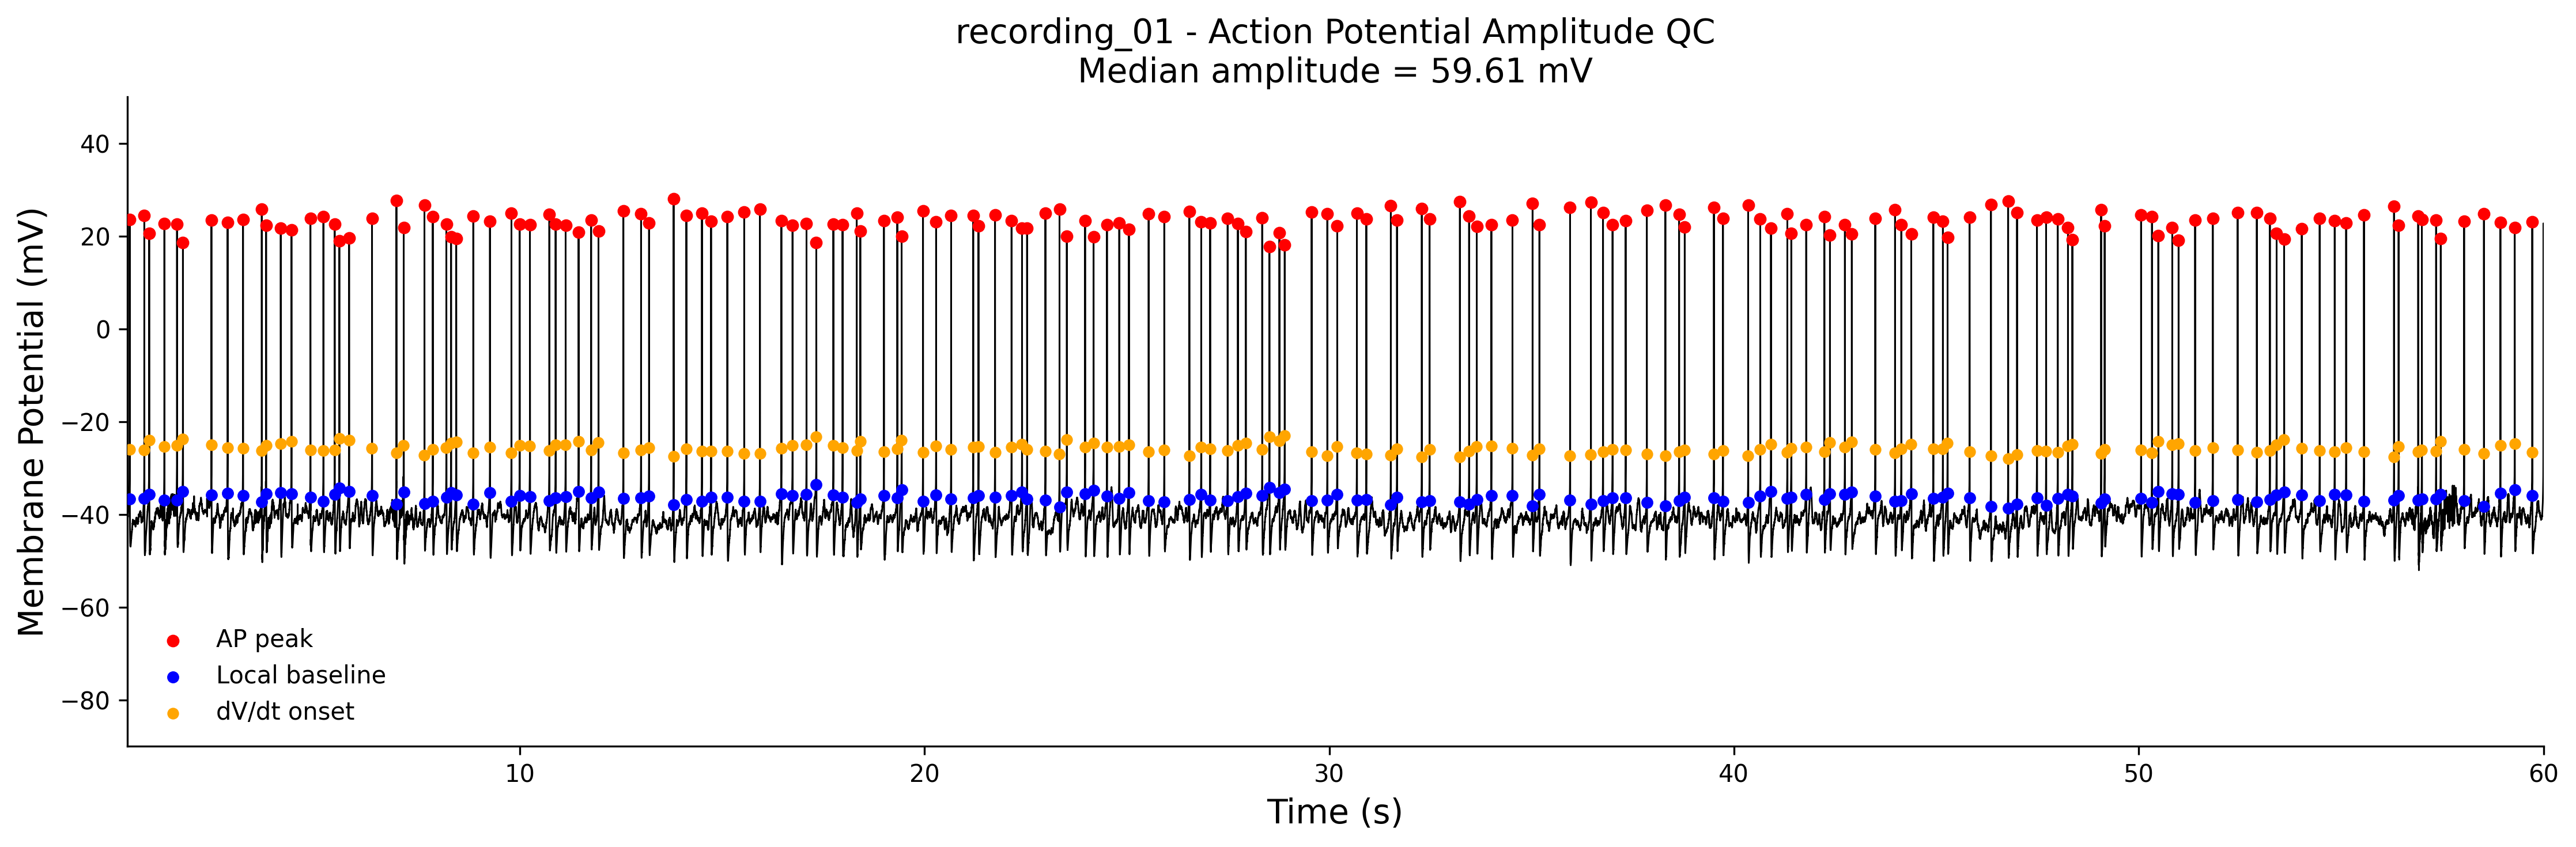

Representative QC results:
Recording: recording_01
Detected spikes: 170
Median AP amplitude: 59.61 mV
Mean AP amplitude: 59.61 mV
Median AP peak: 23.35 mV
Median local baseline: -36.42 mV


In [8]:
# ============================================================
# REPRESENTATIVE QUALITY-CONTROL VISUALIZATION
# ============================================================

# Private file used only to generate the representative QC plot.
# Before uploading to GitHub, this will be changed to "recording_01.asc".
PRIVATE_QC_FILE = "recording_01.asc"

# Public anonymized name displayed in the figure
REPRESENTATIVE_RECORDING_NAME = "recording_01"

qc_file_path = os.path.join(BASE_PATH, PRIVATE_QC_FILE)

qc_summary_df, qc_spike_by_spike_df = analyze_amplitude_recording(
    file_path=qc_file_path,
    recording_name=REPRESENTATIVE_RECORDING_NAME,
    condition_name=CONDITION_NAME,
    start_time_s=START_TIME_S,
    end_time_s=END_TIME_S,
    min_peak_mV=MIN_PEAK_MV,
    min_prominence_mV=MIN_PROMINENCE_MV,
    refractory_period_s=REFRACTORY_PERIOD_S,
    local_baseline_start_ms=LOCAL_BASELINE_START_MS,
    local_baseline_end_ms=LOCAL_BASELINE_END_MS,
    pre_spike_window_ms=PRE_SPIKE_WINDOW_MS,
    dvdt_threshold_mV_per_ms=DVDT_THRESHOLD_MV_PER_MS,
    qc_low_amplitude_mV=QC_LOW_AMPLITUDE_MV,
    qc_high_amplitude_mV=QC_HIGH_AMPLITUDE_MV,
    y_min=Y_MIN,
    y_max=Y_MAX,
    save_figure=True
)

print("Representative QC results:")
print(f"Recording: {REPRESENTATIVE_RECORDING_NAME}")
print(f"Detected spikes: {int(qc_summary_df.loc[0, 'spike_count_detected'])}")
print(f"Median AP amplitude: {qc_summary_df.loc[0, 'median_amplitude_mV']:.2f} mV")
print(f"Mean AP amplitude: {qc_summary_df.loc[0, 'mean_amplitude_mV']:.2f} mV")
print(f"Median AP peak: {qc_summary_df.loc[0, 'median_peak_mV']:.2f} mV")
print(f"Median local baseline: {qc_summary_df.loc[0, 'median_local_baseline_mV']:.2f} mV")